In [2]:
# !nvidia-smi
###############

In [3]:
import glob
import os
import torch
import sys
from metrics_cond import *
import slice_view
import torch.nn.functional as F
import nibabel as nib
from matplotlib import pyplot as plt
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader



# Function to process batch and save

In [4]:

# Normalize tensors
def normalize_tensor(tensor, min_range, max_range):
    min_vals = torch.min(tensor, dim=2).values.min(dim=2).values
    max_vals = torch.max(tensor, dim=2).values.max(dim=2).values
    normalized_tensor = (tensor - min_vals.unsqueeze(2).unsqueeze(3)) / (max_vals.unsqueeze(2).unsqueeze(3) - min_vals.unsqueeze(2).unsqueeze(3))
    normalized_tensor = normalized_tensor * (max_range - min_range) + min_range
    return normalized_tensor
def load_data(model):
    """Load test datasets."""    
    root_path='/home/projects/medimg/ayantika/Ayantika/Data_final/'
    h5_data_path = '/home/projects/medimg/ayantika/Ayantika/h5data_store/'
    region_info_path = '/home/projects/medimg/ayantika/Ayantika/Data_final/'


    model.conf.data_config_path = './config_file_ADNI.yaml'
    model.conf.csv_path_test = root_path+'/ADNI_Data_loader_csv/ADNI_info_test_final.csv'

    model.conf.h5_save_path_test = '/home/projects/medimg/ADNI_data_loc/ADNI_cond_test_ventricle_mask/'
    model.conf.csv_file_name_test = root_path+'/ADNI_Data_loader_csv/ADNI_test_pair_data_info.csv'

    model.conf.csv_mask_name_test= root_path+'/ADNI_Data_loader_csv/ADNI_test_pair_mask_info.csv'
    model.conf.ventricle_mask_root_path= '/home/projects/medimg/ADNI_data_loc/ADNI_ventricle_mask/'

    model.val_data = model.conf.make_dataset(
        path=model.conf.data_config_path,
        csv_path=model.conf.csv_path_test,
        h5_save_path=model.conf.h5_save_path_test,
        csv_file_name=model.conf.csv_file_name_test,
        csv_mask_name=model.conf.csv_mask_name_test,
        ventricle_mask_root_path=model.conf.ventricle_mask_root_path,
        mode_='test'
    )
    print('val data:', len(model.val_data))
    return model.val_data

def create_dataloaders(model, batch_size=50, batch_size_eval=50):
    """Create DataLoaders for test data."""
    test_dataloader = DataLoader(model.val_data, shuffle=False, batch_size=batch_size_eval, num_workers=1, pin_memory=True)
    return test_dataloader
def process_batch_with_hook(batch, model, mode='test', device='cuda'):
    """
    Process a batch, run diffusion, and capture intermediate activations
    from model.ema_model.output_blocks[11].

    Returns:
        pred_x_start: generated follow-up image (tensor)
        res2_acts:    activation tensor from the hooked layer ("res2")
        batch:        original batch (for convenience)
    """
    # dictionary to hold activations
    acts = {}

    def save_activation(name):
        def hook(module, inp, out):
            # handle case where out is a tuple/list
            if isinstance(out, (tuple, list)):
                out = out[0]
            acts[name] = out.detach()
        return hook

    # register hook
    handle = model.ema_model.output_blocks[11].register_forward_hook(
        save_activation("res2")
    )

    with torch.no_grad():
        # put model on GPU and eval mode (similar to original process_batch)
        model.eval()
        model.cuda()
        model.model.eval()
        model.model.cuda()

        # ------------------------------------------------------------------ #
        # 1. Prepare inputs (x_start, x_start_baseline, age_diff, etc.)
        # ------------------------------------------------------------------ #
        # assuming normalize_tensor is the same helper you used before
        x_start = batch['_'+mode+'_image']
#         , 0, 1).to(device)
        x_start_baseline = batch['_'+mode+'_baseline_image']
#     , 0, 1
#         ).to(device)

        # age difference
        age_diff = model.str_list_tensor(batch['Age']) - \
                   model.str_list_tensor(batch['baseline Age'])
        age_diff = age_diff.to(batch['_'+mode+'_image'].dtype)

        # ------------------------------------------------------------------ #
        # 2. Encode baseline with the *modified* call (model.model.encode)
        # ------------------------------------------------------------------ #
        cond_baseline = model.model.encode(batch['_'+mode+'_baseline_image'].to(device))
        # cond_baseline is expected to be a dict, hence cond_baseline['cond']

        # ------------------------------------------------------------------ #
        # 3. Condition vectors and latent shift prediction
        # ------------------------------------------------------------------ #
        cond_vector = torch.zeros(batch['_'+mode+'_image'].shape[0], 12)
        cond_vector, shifts, cond_vector_shift = model.get_data_elements(
            batch, age_diff, cond_vector
        )

        health_state = cond_vector_shift
        cond_vector_shift = cond_vector_shift.to(age_diff.dtype).to(age_diff.device)

        # latent shift predictor
        shift_predictor = model.model.latent_shift_predictor
        shift_predictor.eval()
        shift_new = shift_predictor.forward(cond_vector_shift.cuda())

        # (optional) same zero-age-diff modification
        shift_new_modf = shift_new.clone()
        for ind_, diff in enumerate(age_diff):
            if diff == 0:
                shift_new_modf[ind_][0:50] = shift_new_modf[ind_][450:500]

        # ------------------------------------------------------------------ #
        # 4. Sample xT and render
        # ------------------------------------------------------------------ #
        # noise is not strictly needed here except if you want it explicitly
        noise = torch.randn(
            x_start.shape[0], 1, x_start.shape[2], x_start.shape[3],
            device=x_start.device
        )

        xT = model.encode_stochastic(
            batch['_'+mode+'_baseline_image'].to(device),
            cond_baseline['cond'],
            T=200,
            x_start_baseline=x_start_baseline,
            age_diff=age_diff.to(device),
            health_state=health_state.to(device)
        )

        # The actual forward pass that will trigger the hook
        pred_x_start = model.render(
            xT.to(device),
            {'cond': cond_baseline['cond'] + shift_new_modf},
            T=50,
            mask_mult=False,
            health_state=cond_vector_shift.to(device)
        )

    # remove hook after the forward pass
    handle.remove()

    # retrieve the captured activation
    res2_acts = acts.get("res2", None)

    return pred_x_start, res2_acts,  x_start, x_start_baseline, batch

def save_results(pred_x_start, x_start, x_start_baseline, batch, save_=False, save_path='./save_results/'):
    """Save batch results to a .pt file."""
    
    ## Normalize tensors 
    pred_followup_xT_shift = normalize_tensor(pred_x_start,0,1)
    x_start_ = normalize_tensor(x_start,0,1)
    x_start_baseline_ = normalize_tensor(x_start_baseline,0,1)
    
    # Convert ages to tensors
    starting_age = torch.tensor(float(batch['baseline Age'][0]))
    followup_age = torch.tensor(float(batch['Age'][0]))

    # Print subject info
    print('Subject:', batch['nii path'][0].split('/')[-1])
    print("Baseline Age: ", batch['baseline Age'][0])
    print('Follow-up Age: ', batch['Age'][0])
    print('Cognitive State: ', batch['Health status'][0])

    # Create results dictionary
    save_dict = {
        'pred_followup_xT_shift': pred_followup_xT_shift,
        'x_start_': x_start_,
        'x_start_baseline_': x_start_baseline_,
        'baseline Age': batch['baseline Age'][0],
        'Age': batch['Age'][0],
        'Health status': batch['Health status'],
        'baseline nii path': batch['baseline nii path'][0],
        'nii path': batch['nii path'][0]
    }
    if save_:
        # Generate unique ID and save
        uniq_id = batch['Subject'][0]+'_'+str(round(followup_age.item(),2))+'_'+str(round(starting_age.item(),2))+'.pt'
        if not os.path.exists(save_path):
            os.mkdir(save_path)
        torch.save(save_dict, save_path + uniq_id)
    return save_dict


In [5]:
import AD_DAE_model_call as model_call

In [6]:
# Load model

# root_path_ = '/home/projects/medimg/ayantika/Ayantika/Diff_AE_xstart_w_xbsln_disentangle_unsup/AD_DAE_files/'
# model_AD_DAE = model_call.AD_DAE_model_call_func(root_path=root_path_,\
#                           checkpoint_path = '/home/projects/medimg/ayantika/Ayantika/results/AD_DAE_new_train/ADNI_AD_CN_MCI/',
#                                                  epoch_no = 120)


In [7]:
root_path_ = '/home/projects/medimg/ayantika/Ayantika/Align_DiffAE/'
model_Align_DiffAE = model_call.AD_DAE_model_call_func(root_path=root_path_,\
                          checkpoint_path = '/home/projects/medimg/ayantika/Ayantika/results/Align_cDAE/ADNI_AD_CN_MCI/',
                                                epoch_no = 120)


Seed set to 0


Model params: 129.17 M


In [8]:
# model = model_AD_DAE
model = model_Align_DiffAE
device='cuda'
# .sampler.training_losses

In [9]:
model.val_data = load_data(model)
test_dataloader = create_dataloaders(model, batch_size=50, batch_size_eval=50)

self.data_name ADNI
val data: 31100


In [10]:
# for i, batch in enumerate(test_dataloader):
#     if batch['Subject'][0] == '002_S_0938':
# #     i==28:
#       print(i, batch['Subject'][0],batch['Age'][0],batch['baseline Age'][0],batch['Health status'][0])


In [11]:
for i, batch in enumerate(test_dataloader):
#     if batch['Subject'][0] == '002_S_0938':
#     i==28:
    print(i, batch['Subject'][0],batch['Age'][0],batch['baseline Age'][0],batch['Health status'][0])
    pred_x_start, res2_acts,  x_start, x_start_baseline, batch =process_batch_with_hook(batch, model)
    dict__ = save_results(pred_x_start, x_start, x_start_baseline, batch, \
                  save_=True, save_path='/home/projects/medimg/ayantika/Ayantika/results/Align_cDAE/save_results/')
#         break

0 094_S_1027 69.7 69.1 AD
Subject: ADNI_094_S_1027_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20080220134707189_S32272_I91020.nii
Baseline Age:  69.1
Follow-up Age:  69.7
Cognitive State:  AD
1 094_S_1027 70.2 69.7 AD
Subject: ADNI_094_S_1027_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20080220135429027_S42880_I91029.nii
Baseline Age:  69.7
Follow-up Age:  70.2
Cognitive State:  AD
2 094_S_1027 70.2 70.2 AD
Subject: ADNI_094_S_1027_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20080220135429027_S42880_I91029.nii
Baseline Age:  70.2
Follow-up Age:  70.2
Cognitive State:  AD
3 131_S_0691 65.0 65.0 AD
Subject: ADNI_131_S_0691_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20070904220606390_S26382_I71689.nii
Baseline Age:  65.0
Follow-up Age:  65.0
Cognitive State:  AD
4 131_S_0691 65.0 64.5 AD
Subject: ADNI_131_S_0691_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20070904220606390_S26382_I71689.nii
Baseline Age:  64.5
Follow-up Age:  65.0
Cognitive State:  AD
5 067_S_12

Subject: ADNI_024_S_1307_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20090408161247091_S63424_I141190.nii
Baseline Age:  77.4
Follow-up Age:  77.4
Cognitive State:  AD
43 024_S_1307 76.4 75.9 AD
Subject: ADNI_024_S_1307_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20080308124740769_S46380_I96266.nii
Baseline Age:  75.9
Follow-up Age:  76.4
Cognitive State:  AD
44 024_S_1307 75.9 75.4 AD
Subject: ADNI_024_S_1307_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20071006120703444_S38800_I77053.nii
Baseline Age:  75.4
Follow-up Age:  75.9
Cognitive State:  AD
45 024_S_1307 77.4 76.4 AD
Subject: ADNI_024_S_1307_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20090408161247091_S63424_I141190.nii
Baseline Age:  76.4
Follow-up Age:  77.4
Cognitive State:  AD
46 109_S_1157 86.0 85.5 AD
Subject: ADNI_109_S_1157_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20081201170213296_S58164_I128789.nii
Baseline Age:  85.5
Follow-up Age:  86.0
Cognitive State:  AD
47 109_S_1157 86.0 85.0 AD
Subject:

Subject: ADNI_131_S_0497_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20081024092147063_S53628_I123416.nii
Baseline Age:  77.9
Follow-up Age:  77.9
Cognitive State:  AD
85 131_S_0497 76.4 75.8 AD
Subject: ADNI_131_S_0497_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070828152815376_S24936_I70896.nii
Baseline Age:  75.8
Follow-up Age:  76.4
Cognitive State:  AD
86 131_S_0497 77.9 76.8 AD
Subject: ADNI_131_S_0497_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20081024092147063_S53628_I123416.nii
Baseline Age:  76.8
Follow-up Age:  77.9
Cognitive State:  AD
87 131_S_0497 76.8 76.4 AD
Subject: ADNI_131_S_0497_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070904215006186_S33777_I71669.nii
Baseline Age:  76.4
Follow-up Age:  76.8
Cognitive State:  AD
88 127_S_1382 66.4 66.4 AD
Subject: ADNI_127_S_1382_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20090721114554064_S66581_I149834.nii
Baseline Age:  66.4
Follow-up Age:  66.4
Cognitive State:  AD
89 127_S_1382 66.4 65.4 AD
Subject: A

Subject: ADNI_023_S_0084_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_2_Br_20081002103336486_S25511_I118993.nii
Baseline Age:  76.0
Follow-up Age:  76.5
Cognitive State:  AD
127 023_S_0084 77.5 77.5 AD
Subject: ADNI_023_S_0084_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20080224132527438_S44784_I92169.nii
Baseline Age:  77.5
Follow-up Age:  77.5
Cognitive State:  AD
128 062_S_0730 72.7 72.7 AD
Subject: ADNI_062_S_0730_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20081023151703543_S54793_I123220.nii
Baseline Age:  72.7
Follow-up Age:  72.7
Cognitive State:  AD
129 062_S_0730 72.7 71.8 AD
Subject: ADNI_062_S_0730_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20081023151703543_S54793_I123220.nii
Baseline Age:  71.8
Follow-up Age:  72.7
Cognitive State:  AD
130 062_S_0730 71.8 70.7 AD
Subject: ADNI_062_S_0730_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20071221155904576_S37052_I85959.nii
Baseline Age:  70.7
Follow-up Age:  71.8
Cognitive State:  AD
131 062_S_0730 72.7 71.3 AD

Subject: ADNI_057_S_0643_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20100111143946721_S70434_I163000.nii
Baseline Age:  72.5
Follow-up Age:  74.5
Cognitive State:  CN
169 057_S_0643 74.5 74.5 CN
Subject: ADNI_057_S_0643_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20100111143946721_S70434_I163000.nii
Baseline Age:  74.5
Follow-up Age:  74.5
Cognitive State:  CN
170 057_S_0643 72.1 71.5 CN
Subject: ADNI_057_S_0643_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20071125143831008_S25942_I83126.nii
Baseline Age:  71.5
Follow-up Age:  72.1
Cognitive State:  CN
171 941_S_1195 80.1 77.1 CN
Subject: ADNI_941_S_1195_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20101111124642985_S80556_I204834.nii
Baseline Age:  77.1
Follow-up Age:  80.1
Cognitive State:  CN
172 941_S_1195 79.1 77.8 CN
Subject: ADNI_941_S_1195_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20090423140018018_S63583_I142483.nii
Baseline Age:  77.8
Follow-up Age:  79.1
Cognitive State:  CN
173 941_S_1195 80.1 79.1 CN
Subjec

...

Subject: ADNI_051_S_1331_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20081014085902488_S53103_I120544.nii
Baseline Age:  77.4
Follow-up Age:  78.0
Cognitive State:  MCI
420 051_S_1331 78.4 78.0 MCI
Subject: ADNI_051_S_1331_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20081204172528192_S60241_I129331.nii
Baseline Age:  78.0
Follow-up Age:  78.4
Cognitive State:  MCI
421 057_S_1269 75.6 75.6 MCI
Subject: ADNI_057_S_1269_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20091210145040170_S63312_I160680.nii
Baseline Age:  75.6
Follow-up Age:  75.6
Cognitive State:  MCI
422 057_S_1269 74.1 73.6 MCI
Subject: ADNI_057_S_1269_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070925105044981_S38177_I75082.nii
Baseline Age:  73.6
Follow-up Age:  74.1
Cognitive State:  MCI
423 057_S_1269 75.1 74.6 MCI
Subject: ADNI_057_S_1269_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20081020083131899_S55000_I122141.nii
Baseline Age:  74.6
Follow-up Age:  75.1
Cognitive State:  MCI
424 057_S_1269 74.6 74.1 

Subject: ADNI_022_S_1394_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20101108140026145_S88279_I203301.nii
Baseline Age:  78.9
Follow-up Age:  80.3
Cognitive State:  MCI
461 022_S_0961 76.0 76.0 MCI
Subject: ADNI_022_S_0961_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20100106085230491_S76328_I162260.nii
Baseline Age:  76.0
Follow-up Age:  76.0
Cognitive State:  MCI
462 022_S_0961 76.0 72.9 MCI
Subject: ADNI_022_S_0961_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20100106085230491_S76328_I162260.nii
Baseline Age:  72.9
Follow-up Age:  76.0
Cognitive State:  MCI
463 022_S_0961 75.0 74.4 MCI
Subject: ADNI_022_S_0961_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20081204142203044_S59586_I129241.nii
Baseline Age:  74.4
Follow-up Age:  75.0
Cognitive State:  MCI
464 022_S_0961 76.0 73.5 MCI
Subject: ADNI_022_S_0961_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20100106085230491_S76328_I162260.nii
Baseline Age:  73.5
Follow-up Age:  76.0
Cognitive State:  MCI
465 022_S_0961 74.

Subject: ADNI_036_S_0656_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20100112100526632_S70534_I163145.nii
Baseline Age:  82.6
Follow-up Age:  85.7
Cognitive State:  MCI
502 036_S_0656 84.7 84.2 MCI
Subject: ADNI_036_S_0656_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20081023125543720_S54193_I123083.nii
Baseline Age:  84.2
Follow-up Age:  84.7
Cognitive State:  MCI
503 036_S_0656 85.7 85.7 MCI
Subject: ADNI_036_S_0656_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20100112100526632_S70534_I163145.nii
Baseline Age:  85.7
Follow-up Age:  85.7
Cognitive State:  MCI
504 036_S_0656 83.7 83.2 MCI
Subject: ADNI_036_S_0656_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070904202551074_S35050_I71536.nii
Baseline Age:  83.2
Follow-up Age:  83.7
Cognitive State:  MCI
505 131_S_0384 82.0 79.9 MCI
Subject: ADNI_131_S_0384_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20080514123633881_S49312_I105521.nii
Baseline Age:  79.9
Follow-up Age:  82.0
Cognitive State:  MCI
506 131_S_0384 84.1 81.1 

Subject: ADNI_127_S_1419_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20100108163511697_S72592_I162969.nii
Baseline Age:  79.6
Follow-up Age:  80.1
Cognitive State:  MCI
543 127_S_1419 80.1 80.1 MCI
Subject: ADNI_127_S_1419_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20100108163511697_S72592_I162969.nii
Baseline Age:  80.1
Follow-up Age:  80.1
Cognitive State:  MCI
544 127_S_1419 79.1 78.6 MCI
Subject: ADNI_127_S_1419_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20081017081605828_S55777_I121684.nii
Baseline Age:  78.6
Follow-up Age:  79.1
Cognitive State:  MCI
545 006_S_1130 71.8 71.2 MCI
Subject: ADNI_006_S_1130_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20070913151820731_S35285_I73037.nii
Baseline Age:  71.2
Follow-up Age:  71.8
Cognitive State:  MCI
546 006_S_1130 73.4 73.0 MCI
Subject: ADNI_006_S_1130_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20090223160241850_S62673_I136754.nii
Baseline Age:  73.0
Follow-up Age:  73.4
Cognitive State:  MCI
547 006_S_1130 74.3 7

Subject: ADNI_005_S_0324_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20080430143419255_S49114_I104357.nii
Baseline Age:  77.0
Follow-up Age:  77.5
Cognitive State:  MCI
584 005_S_0324 78.6 76.0 MCI
Subject: ADNI_005_S_0324_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20090723163223810_S68159_I150219.nii
Baseline Age:  76.0
Follow-up Age:  78.6
Cognitive State:  MCI
585 005_S_0324 78.6 76.5 MCI
Subject: ADNI_005_S_0324_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20090723162510239_S68167_I150214.nii
Baseline Age:  76.5
Follow-up Age:  78.6
Cognitive State:  MCI
586 005_S_0324 78.6 76.5 MCI
Subject: ADNI_005_S_0324_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20090723162510239_S68167_I150214.nii
Baseline Age:  76.5
Follow-up Age:  78.6
Cognitive State:  MCI
587 016_S_1149 84.6 84.4 MCI
Subject: ADNI_016_S_1149_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20071229175802518_S28286_I86336.nii
Baseline Age:  84.4
Follow-up Age:  84.6
Cognitive State:  MCI
588 016_S_1149 84.6

In [38]:
# mode='test'
# x_start = batch['_'+mode+'_image']
# x_start_baseline = batch['_'+mode+'_baseline_image'].to(device)
# noise = torch.randn(x_start.shape[0], 1, x_start.shape[2], x_start.shape[3], device=x_start.device)
# model.model.to(device)

# pred_x_start, res2_acts,  x_start, x_start_baseline, batch =process_batch_with_hook(batch, model)
# dict__ = save_results(pred_x_start, x_start, x_start_baseline, batch, \
#                       save_=True, save_path='/home/projects/medimg/ayantika/Ayantika/results/cDAE/save_results/')

Subject: ADNI_022_S_0129_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20080229153509900_S45881_I94405.nii
Baseline Age:  80.8
Follow-up Age:  82.3
Cognitive State:  AD


## Visualization

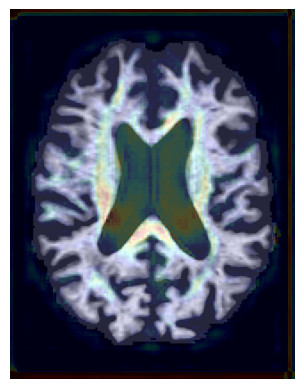

In [60]:
from matplotlib import pyplot as plt
indx_ = 35
plt.figure()
plt.imshow(np.rot90(x_start[indx_,0,:,:].cpu(),k=1),cmap='gray',vmin=0,vmax=1)
plt.imshow(np.rot90((-res2_acts[indx_,:,:,:].mean(dim=0).detach().cpu()),k=1), alpha=0.2,cmap='jet',vmin=-1,vmax=1)

plt.imshow(np.rot90((x_start[indx_,0,:,:].cpu()>-1),k=1),cmap='gray', alpha=0.15)
plt.axis('off')
# plt.savefig('./save_results/attention_Align_cDAE_ADNI_062_S_0793_69.5_71.3.png',dpi=500.0,bbox_inches='tight')
plt.show()

# plt.colorbar()
# acts["res2"].shape

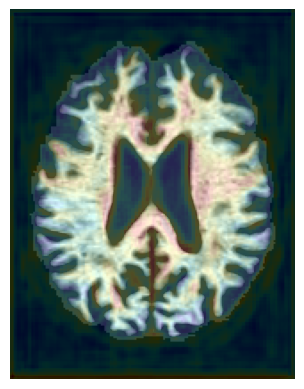

In [40]:
from matplotlib import pyplot as plt
indx_ = 40
plt.figure()
plt.imshow(np.rot90(x_start[indx_,0,:,:],k=1),cmap='gray',vmin=0,vmax=1)
plt.imshow(np.rot90((-res2_acts[indx_,:,:,:].mean(dim=0).detach().cpu()),k=1), alpha=0.2,cmap='jet',vmin=-1,vmax=1)

plt.imshow(np.rot90((x_start[indx_,0,:,:]>-1),k=1),cmap='gray', alpha=0.15)
plt.axis('off')
# plt.savefig('./save_results/attention_cDAE_ADNI_062_S_0793_69.5_71.3.png',dpi=500.0,bbox_inches='tight')
plt.show()
# plt.axes('off')

# plt.colorbar()
# acts["res2"].shape

In [346]:
# from matplotlib import pyplot as plt
# plt.imshow(-acts["res2"][25,:,:,:].mean(dim=0).detach().cpu())
# plt.axis('off')
# # plt.colorbar()
# # acts["res2"].shape

In [347]:
# from matplotlib import pyplot as plt
# plt.imshow(acts["res2"][25,10,:,:].detach().cpu())
# plt.colorbar()
# # acts["res2"].shape

In [61]:
mask_=(x_start.to(device) - x_start_baseline.to(device))[:,:,:,:]<torch.tensor(-0.4)

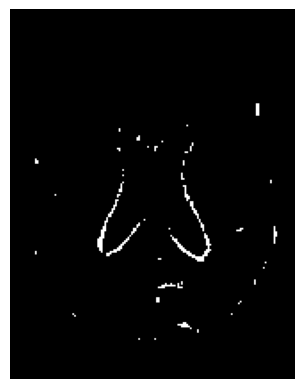

In [62]:
plt.imshow(np.rot90(mask_[indx_,0,:,:].cpu(),k=1),cmap='gray')
plt.axis('off')
# plt.savefig('./save_results/progression_mask_gt_ADNI_062_S_0793_69.5_71.3.png',dpi=500.0,bbox_inches='tight')
plt.show()

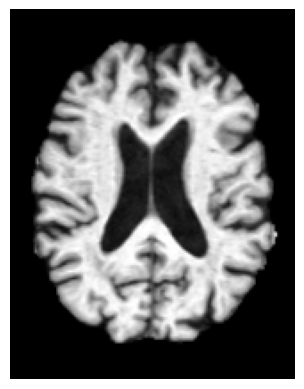

In [63]:
plt.imshow(np.rot90(pred_x_start[indx_,0,:,:].cpu().detach(),k=1), cmap='gray')
plt.axis('off')
# plt.savefig('./save_results/pred_x_f_Align_cDAE_ADNI_062_S_0793_69.5_71.3.png',dpi=500.0,bbox_inches='tight')

# plt.savefig('./save_results/pred_x_f_cDAE_ADNI_062_S_0793_69.5_71.3.png',dpi=500.0,bbox_inches='tight')
plt.show()

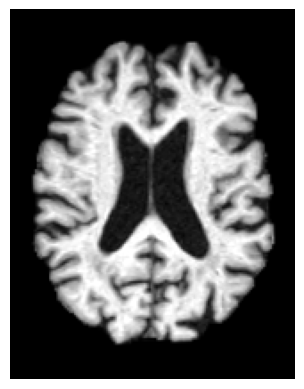

In [64]:
plt.imshow(np.rot90(x_start[indx_,0,:,:].cpu().detach(),k=1), cmap='gray')
plt.axis('off')
# plt.savefig('./save_results/x_f_Align_cDAE_ADNI_062_S_0793_69.5_71.3.png',dpi=500.0,bbox_inches='tight')
plt.show()

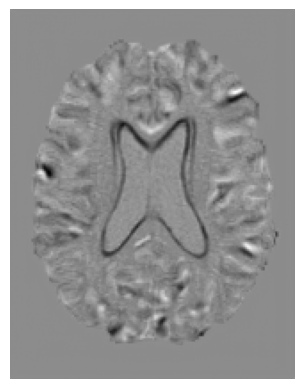

In [65]:
image_show = (pred_x_start[indx_,0,:,:].cpu().detach()) - (normalize_tensor(x_start_baseline[:,:,:,:],0,1).cpu().detach()[indx_,0,:,:]) 


plt.imshow(np.rot90(image_show,k=1), cmap='gray')
plt.axis('off')
# plt.savefig('./save_results/pred_x_f_res_x_b_Align_cDAE_ADNI_062_S_0793_69.5_71.3.png',dpi=500.0,bbox_inches='tight')
# plt.savefig('./save_results/pred_x_f_res_x_b_cDAE_ADNI_062_S_0793_69.5_71.3.png',dpi=500.0,bbox_inches='tight')

plt.show()

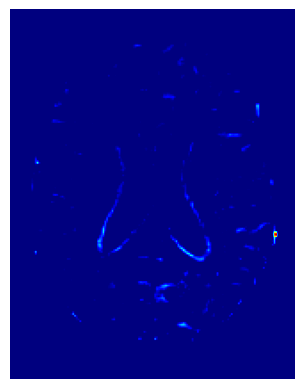

In [68]:
image_show = (pred_x_start[indx_,0,:,:].cpu().detach()) - (normalize_tensor(x_start[:,:,:,:],0,1).cpu().detach()[indx_,0,:,:]) 


plt.imshow(np.rot90(np.clip(image_show,0.1,0.9),k=1), cmap='jet')
plt.axis('off')
# plt.savefig('./save_results/pred_x_f_res_x_f_Align_cDAE_ADNI_062_S_0793_69.5_71.3.png',dpi=500.0,bbox_inches='tight')
# plt.savefig('./save_results/pred_x_f_res_x_f_cDAE_ADNI_062_S_0793_69.5_71.3.png',dpi=500.0,bbox_inches='tight')

plt.show()

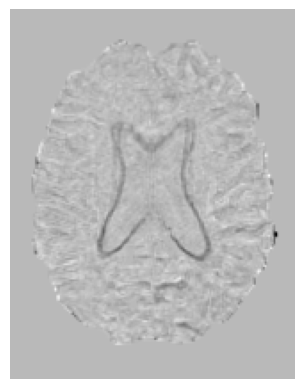

In [67]:


image_show = (normalize_tensor(x_start[:,:,:,:],0,1)[indx_,0,:,:].cpu().detach()) - (normalize_tensor(x_start_baseline[:,:,:,:],0,1).cpu().detach()[indx_,0,:,:])
plt.imshow(np.rot90(image_show,k=1), cmap='gray')
plt.axis('off')
# plt.savefig('./save_results/x_f_res_x_b_Align_cDAE_ADNI_062_S_0793_69.5_71.3.png',dpi=500.0,bbox_inches='tight')
plt.show()

In [91]:
#3D Loading of Ground-truth
slc = slice_view.slicer((save_dict['x_start_'])[:,0,:,:].detach().cpu())
slc.slicer_view()

interactive(children=(Dropdown(description='slice_view', options=('x', 'y', 'z'), value='x'), IntSlider(value=…

<function ipywidgets.widgets.interaction._InteractFactory.__call__.<locals>.<lambda>(*args, **kwargs)>

In [92]:
#3D Loading of Generated Images
slc = slice_view.slicer((save_dict['pred_followup_xT_shift'])[:,0,:,:].detach().cpu())
slc.slicer_view()

interactive(children=(Dropdown(description='slice_view', options=('x', 'y', 'z'), value='x'), IntSlider(value=…

<function ipywidgets.widgets.interaction._InteractFactory.__call__.<locals>.<lambda>(*args, **kwargs)>